# Metody analizy danych. Lab 1. Biblioteka numpy, część 1

# 1. Wstęp

Biblioteka numpy jest biblioteką dedykowaną do obliczeń numerycznych, która jest zaimplementowana głównie w języku C. Jej głównym obiektem danych jest tablica wielowymiarowa pozwalająca na pracę z wieloma typami danych, ale jednorodnych. Biblioteka ta dostarcza również wielu metod matematycznych np. z zakresu algebry liniowej, statystyki czy generatorów liczb pseudolosowych.

> **Oficjalna strona z dokumentacją do wersji 2.4**: https://numpy.org/doc/2.4/index.html

## 1.1 Instalacja biblioteki numpy

In [10]:
!pip install numpy

In [11]:
np.__version__

'2.0.2'

In [12]:
import numpy as np

# 2. Tablica `numpy.ndarray`

 ## 2.1 Sposoby inicjalizacji tablicy

> **Dokumentacja**: https://numpy.org/doc/2.4/reference/routines.array-creation.html

In [13]:
# wbudowana funkcja dir wyświetla nam zbiór właściwości oraz metod, które są możliwe do
# wywołania dla podanego typu obiektu - jak widań ndarray (n-dimensional array) posiada
# ich całkiem sporo, ale ten sposób ich wyświetlenie można potraktować jako ciekawostkę lub szybki sposób na przypomnienie sobie nazwy jednej z nich
# Lepszym pomysłem na początek jest oficjalna dokumentacja.
dir(np.ndarray)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',


In [14]:
# tablice numpy możemy inicjalizować na wiele sposobów,
# np. rzutując (konwertując) inne popularne typy danych
lista = [1, 2, 3, 4, 5]
arr = np.array(lista)
arr, type(arr)

(array([1, 2, 3, 4, 5]), numpy.ndarray)

In [15]:
# czy możliwe jest również rzutowanie dla list wielopoziomowych (zagnieżdżonych)?
lista_zagniezdzona = [[i*j for j in range(1, 6)] for i in range(1, 6)]
display(lista_zagniezdzona)
len(lista_zagniezdzona)

[[1, 2, 3, 4, 5],
 [2, 4, 6, 8, 10],
 [3, 6, 9, 12, 15],
 [4, 8, 12, 16, 20],
 [5, 10, 15, 20, 25]]

5

In [16]:
arr_nested = np.array(lista_zagniezdzona)
arr_nested

array([[ 1,  2,  3,  4,  5],
       [ 2,  4,  6,  8, 10],
       [ 3,  6,  9, 12, 15],
       [ 4,  8, 12, 16, 20],
       [ 5, 10, 15, 20, 25]])

In [17]:
lista_zagniezdzona_asym = [[x for x in range(1, y)] for y in range(1, 6)]
lista_zagniezdzona_asym

[[], [1], [1, 2], [1, 2, 3], [1, 2, 3, 4]]

In [24]:
# tak już nie możemy!
arr_nested_asym = np.array(lista_zagniezdzona_asym)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.

In [20]:
np.array(range(10))

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [21]:
# biblioteka numpy posiada własną metodę adekwatną do wbudowanej funkcji range
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [22]:
# parametry określamy adekwatnie do wbudowanej funkcji range(start, stop, step)
np.arange(2, 21, 2)

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20])

In [23]:
# macierz wypełniona jedynkami (możemy przekazać skalar jeżeli ma to być tablica jednowymiarowa lub odpowiednią krotkę dla tablic wielowymiarowych)
display(np.ones(5))
display(np.ones((5,5)))

# lub zerami
display(np.zeros(5))
display(np.zeros((3,1)))

array([1., 1., 1., 1., 1.])

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

array([0., 0., 0., 0., 0.])

array([[0.],
       [0.],
       [0.]])

In [25]:
# linspace tworzy przestrzeń wartości w przedziale (tu od 1 do 10) w określonej liczebności
np.linspace(1,10, 100)

array([ 1.        ,  1.09090909,  1.18181818,  1.27272727,  1.36363636,
        1.45454545,  1.54545455,  1.63636364,  1.72727273,  1.81818182,
        1.90909091,  2.        ,  2.09090909,  2.18181818,  2.27272727,
        2.36363636,  2.45454545,  2.54545455,  2.63636364,  2.72727273,
        2.81818182,  2.90909091,  3.        ,  3.09090909,  3.18181818,
        3.27272727,  3.36363636,  3.45454545,  3.54545455,  3.63636364,
        3.72727273,  3.81818182,  3.90909091,  4.        ,  4.09090909,
        4.18181818,  4.27272727,  4.36363636,  4.45454545,  4.54545455,
        4.63636364,  4.72727273,  4.81818182,  4.90909091,  5.        ,
        5.09090909,  5.18181818,  5.27272727,  5.36363636,  5.45454545,
        5.54545455,  5.63636364,  5.72727273,  5.81818182,  5.90909091,
        6.        ,  6.09090909,  6.18181818,  6.27272727,  6.36363636,
        6.45454545,  6.54545455,  6.63636364,  6.72727273,  6.81818182,
        6.90909091,  7.        ,  7.09090909,  7.18181818,  7.27

In [26]:
# tablice numpy można poddawać zmianom kształu m.in. poprzez metodę reshape, co w połączeniu z różnymi metodami ich inicjalizacji
# daje dodatkowe możliwości - ale tu musimy pamiętać o symetrii tablicy, do której chcemy ją przekształcić (liczba elementów musi
# w tablicy docelowej musi być równa liczbie elementów w tablicy źródłowej)
np.arange(9).reshape((3,3))

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [27]:
# np.diag zwraca tablicę dwuwymiarową kwadratową o wymiarach (v x v) + abs(k) gdzie v to wartość pierwszego argumentu przekazanego w
# wywołaniu tej funkcji, który to jest obiektem iterowalnym zawierającym elementy, które zostaną umieszczone na przekątnej
# tej macierzy. Jeżeli drugi argument tej funkcji  k (opcjonalny) nie zostanie określony, lub posiada wartość 0, to elementy
# zostaną umieszczone na głównej przekątnej, w przeciwnym wypadku elementy zostaną umieszczone na k-tej lub -k-tej przekątnej
# oddalonej od głównej przekątnej
np.diag((1,2,3,4))

array([[1, 0, 0, 0],
       [0, 2, 0, 0],
       [0, 0, 3, 0],
       [0, 0, 0, 4]])

In [28]:
np.diag(np.arange(5), 1)

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 2, 0, 0],
       [0, 0, 0, 0, 3, 0],
       [0, 0, 0, 0, 0, 4],
       [0, 0, 0, 0, 0, 0]])

In [29]:
np.diag(np.arange(5), -1)

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 2, 0, 0, 0],
       [0, 0, 0, 3, 0, 0],
       [0, 0, 0, 0, 4, 0]])

In [30]:
# funkcja diag pozwala również na ekstrakcję przekątnej z istniejącej tablicy
arr = np.arange(1, 17).reshape((4,4))
print(arr)
print(np.diag(arr))
print(np.diag(arr, -1))

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
[ 1  6 11 16]
[ 5 10 15]


## 2.2 Wybrane właściwości (ang. properties) tablic numpy

In [31]:
# informacje o liczbie elementów, liczbie wymiarów oraz o wielkościach każdego wymiaru
arr.size, arr.ndim, arr.shape

(16, 2, (4, 4))

In [32]:
# shape dla macierzy najpierw informuje nas o liczbie wierszy, a następnie o liczbie kolumn
arr = np.zeros((4,3))
display(arr)
arr.shape

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

(4, 3)

In [33]:
# odczytywanie zawartości tablic dla wymiarów 2+ jest już nieco trudniejsze
arr = np.ones((3,3,3))
arr

array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]])

In [34]:
!pip install matplotlib

array([[[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]],

       [[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]],

       [[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]]])

[[[ True  True  True]
  [False False False]
  [ True  True  True]]

 [[ True  True  True]
  [False False False]
  [ True  True  True]]

 [[ True  True  True]
  [False False False]
  [ True  True  True]]]


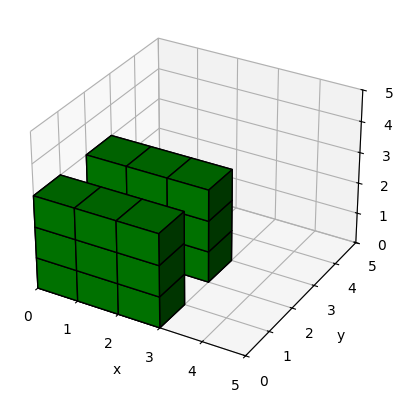

In [35]:
# przykład zaczerpnięty z: https://matplotlib.org/stable/gallery/mplot3d/voxels.html#sphx-glr-gallery-mplot3d-voxels-py

import matplotlib.pyplot as plt

# inicjalizacja tablicy 3 x 3 x 3
# współrzędne (x, z, y)
x = np.ones((3, 3, 3))

# po prawej stosujemy filtrowanie tablicy x warunkiem < 3, co powoduje zwrócenie
# tablicy o tych samych wymiarach, gdzie wartość spełniająca warunek zostanie
# zapisana jako wartość logiczna True, a jeżeli go nie spełnia - jako False
# chociaż można tej konwersji dokonać na kilka sposobów
cube1 = (x < 3)

# sprawdzamy co jest teraz w środku tej tablicy
display(cube1)

# cube1[:,:,1] = False
# cube1[1,:,:] = False
cube1[:,1,:] = False
print(cube1)

colors = np.empty(cube1.shape, dtype=object)
colors[cube1] = 'green'

ax = plt.figure().add_subplot(projection='3d')
ax.axes.set_xlim3d(left=0, right=5)
ax.axes.set_ylim3d(bottom=0, top=5)
ax.axes.set_zlim3d(bottom=0, top=5)
ax.voxels(cube1, facecolors=colors, edgecolor='k')


plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
# typ danych tablicy (przypominam - są jednorodne)
arr.dtype

In [ ]:
# Numpy oferuje wiele typów danych, które mogą być określone jako pojemnik informacji w tablicach numpy.
# Te typy nie pokrywają się 1:1 z typami, które znamy ze standardowej biblioteki Pythona, gdyż wciąż "pod spodem"
# mamy implementację w języku C.
# Zaprezentuję tutaj kilka przykładów, ale liczba wszystkich dostępnych typów jest rozbudowana, więc
# odsyłam do dokumentacji dla pełnej referencji.

# Jak zapewne już zostało to zauważone, typ danyc jest nadawany dla tablicy automatycznie jeżeli nie określimy go w
# trakcie jej inicjalizacji. Nie zawsze będzie się to jednak odbywało optymalnie jeżeli chodzi o utylizację pamięci dla
# danych w tej tablicy.

def print_details(np_arr):
    print(np_arr, np_arr.dtype, np_arr.itemsize, np_arr.nbytes)

# Możemy określić typ na etapie tworzenia tablicy.
arr_int = np.arange(1, 11, dtype='i') # zazwyczaj int32 lub int64
arr_int2 = np.arange(1, 11, dtype='i4') # lub np.int32
arr_int3 = np.arange(1, 11, dtype='i1') # lub np.int8
arr_int4 = np.arange(1, 11, dtype='i2') # lub np.int16
arr_int5 = np.arange(1, 11, dtype='i8') # lub np.int64

print_details(arr_int)
print_details(arr_int2)
print_details(arr_int3)
print_details(arr_int4)
print_details(arr_int5)

In [ ]:
# każdy z tych typów posiada również odpowiednik bez znaku - to znaczy, że w przeciwieństwie do przykładów w poprzednim listingu
# liczby całkowite są przechowywane bez znaku, co podwaja zakres wartości dziesiętnych, które można przypisać do takiej zmiennej

arr_uint1 = np.arange(1, 11, dtype='u4') # lub np.int32
arr_uint2 = np.arange(1, 11, dtype='u8') # lub np.int64

print_details(arr_uint1)
print_details(arr_uint2)

In [ ]:
# typy zmiennoprzecinkowe
# float - f8 - 8 bajtów (to samo co float64)
# float16 - f2 - 2 bajty
# float32 - f - 4 bajty
# float64 - d - 8 bajtów

arr_1 = np.arange(1, 11, dtype='float16')
arr_2 = np.arange(1, 11, dtype='float32')
arr_3 = np.arange(1, 11, dtype='float64')

print_details(arr_1)
print_details(arr_2)
print_details(arr_3)

In [ ]:
# inne typy danych

# bool
bool_arr = np.arange(1, 11, dtype='b')
# łańcuch znaków - unicode
unknown_arr = np.array(['Ala', 'ma', 'kota'])
unknown_arr2 = np.array(list('Zgadnij'))


print_details(bool_arr)
print_details(unknown_arr)
print_details(unknown_arr2)

## 2.3 Wybrane operacje na tablicach numpy

### 2.3.1 Zmiana typu danych tablicy

In [ ]:
# konwersja typu danych w tablicy jest możliwa
arr =  np.arange(100_000, 8_000_000, 100_000)
print(arr)
print(arr.dtype)
print(arr.astype(np.uint32))
print(arr.astype(np.uint16))
print(arr.astype(np.uint8))

In [ ]:
# Czy wiemy co tu się stało?
# Spróbujmy to wyjaśnić. Weźmiemy po uwagę 5 pierwszych wartości z tablicy
vals = list(arr[:5])

for val in vals:
    print(f'Oryginalna: {val}, binarnie: {bin(val)},\
    bin 16: {bin(val)[:-17:-1][::-1]} , dziesiętnie {int(bin(val)[:-17:-1][::-1], base=2)}\
    bin 8: {bin(val)[:-9:-1][::-1]} , dziesiętnie {int(bin(val)[:-9:-1][::-1], base=2)}')

> UWAGA! Konwersja danych może zakończyć się stratą precyzji! Należy najpier przeprowadzić analizę danych, które chcemy poddać konwersji.

### 2.3.2 Czym jest i jak działa broadcasting

In [ ]:
# wykonanie obliczeń na każdym elemencie listy - dla przypomnienia
lista = list(range(1, 11))
print(lista)

for idx in range(len(lista)):
    lista[idx] = lista[idx] * 2

print(lista)

# albo bardziej pythonicznie

lista = [elem * 2 for elem in lista]
print(lista)

In [ ]:
# w przypadku numpy sytuacja ma się inaczej

arr = np.arange(1,11)
print(arr)
print(arr * 2) # operacja jest wykonywana element-wise czyli na każdym elemencie tablicy

In [ ]:
# również większość funkcji biblioteki numpy akceptuje tablicę jako argument wejściowy
# tu poniżej, wyliczymy pierwiastek z każdej wartości tablicy
np.sqrt(arr)

### 2.3.3 Indeksowanie i wycinanie

In [ ]:
# mechanizm dostępu do tablic numpy jest analogiczny do tego znanego z obiektów iterowalnych natywnego Pythona
arr = np.arange(1, 11)
print(arr[0])

print(arr[-1])

print(arr[:5])

In [ ]:
# sytuacja wygląda nieco inaczej w przypadku tablic wielowymiarowych

arr = np.arange(1, 17).reshape((4,4))
print(arr)

# podajemy parametry dla każdego wymiaru
print(arr[0,0])
print(arr[:,0]) # pierwsza kolumna
print(arr[0,:]) # pierwszy wiersz
print(arr[0:2,0:2]) # tablica 2 wymiarowa

In [ ]:
# do wycinków tablic możemy również przypisać wartości

arr[:,0] = 0
arr

In [ ]:
# Jeżeli przywołamy teraz przykład tablicy, która została następnie wyświetlona na wykresie
# to mieliśmy tam do czynienia z tablicą boolowaską, która nazywan jest również mapą boolowską.
# Nazwa ta nawiązuje do operacji, które dzięki takim tablicom można wykonać na innych tablicach.
# Taka mapa pozwala na wycinanie, przypisywanie lub wykonanie funkcji dla każdej wartości tablicy,
# do której taką mapę "przyłożymy" tzn. że mapa spowoduje wykonanie operacji dla każdej wartości
# logicznej True z mapy i pominie operację dla każdej wartości False. Poniżej przykłady.
arr = np.arange(1, 17).reshape((4,4))
print(arr)

# prosty warunek - zwraca mapę, króta ma takie same wymiary i wszędzie tam gdzie warunek jest spełniony przyjmuje wartość True
print((arr < 10))

# jeżeli teraz przyłożymy taką mapę do oryginalnej tablicy...
print(arr[(arr < 10)])
# to otrzymamy na wyjściu tylko wartości gdzie w mapie jest True, ale wymiar już nie zostanie zachowany

# istnieją jeszcze inne sposoby, ale zostaną zaprezentowane na kolejnych zajęciach

## 2.4 Porównanie wydajności

Wiemy już, że poznanie bibblioteki numpy jest potrzebne aby sprawnie pracować następnie z biblioteką pandas, która jest niezwykle popularna w kontekście analizy danych. Ważnym aspektem jest również prędkość przetwarzania, którą oferuje numpy, zwłaszcza w kontekście porównania ze standardową biblioteką Pythona i adekwatnymi obliczeniami.

Poniżej zaprezentowano kilka przykładów porównania wydajności różnych fragmentów kodu Pythona z wykorzystaniem biblioteki timeit.

In [ ]:
from timeit import timeit


setup= """
import numpy as np
"""

setup_2 = """
from array import array
"""

stmt1 = """list(range(1, 100001))"""
stmt2 = """np.arange(1, 100001)"""
stmt3 = """array('I', range(1, 100001))"""

timeit(stmt=stmt1, number=1000), timeit(stmt=stmt2, setup=setup, number=1000), timeit(stmt=stmt3, setup=setup_2, number=1000)

Widać powyżej jaka jest różnica w prędkości pomiędzy standardowymi listami a tablicą numpy w tym konkretnym przypadku, w którym tworzymy tablicę 100000 wartości typu int. Całość powtórzona jest 1000 razy dla uśrednienia warunków.

## Zadania


**Zadanie 1**  
Stwórz i wyświetl tablicę składającą się z 10 kolejnych wartości całkowitych w przedziale [1,10].

**Zadanie 2**   
Zmień typ wartości w tablicy z zadania 1 na float32. Wyświetl tę tablicę.

**Zadanie 3**  
Stwórz tablicę zawierającą kolejne potęgi liczby 2 dla wykładników od 2 do 16.

**Zadanie 4**  
Utwórz tablicę numpy o wymiarach 5x5 z kolejnymi wartościami całkowitoliczbowymi od 1 do 25 i następnie wyświetl:
* ostatnią wartość z tablicy (jest to wartość znajdująca się na ostatnich indeksach wiersza i kolumny)
* drugą kolumnę,
* trzeci wiesz,
* główną przekątną,
* tablicę, która zawiera wartości 9,10,14 oraz 15 (tablica ma kształt 2 x 2)

**Zadanie 5**  
Bazując na przykładach powyżej oraz wykresie z punktu 2.2 wyświetl tę samą tablicę (3 x 3) w poniższych postaciach:
* widoczne są tylko elementy dla współrzędnych y = 1 (x to oś pozioma, y to oś pionowa, z to "głębia")
* widoczne są wartości dla z = 1 oraz z = 3 i wszystkich wartości x oraz y (to tak jakby dwie kolumny tej kostki 3 x 3 x 3 - pierwsza i ostatnia).

**Zadanie 6**  
Bazując na przykładzie z podpunktu 2.3.2 przygotuj test czasu wykonania dla trzech poniższych przypadków:
* inicjalizacja listy 10000 wartości całkowitoliczbowych oraz przemnożenie każdego elementu przez liczbę 2 wykorzystując zapis z pętlą for
* tak jak powyżej, ale z wykorzystaniem list comprehension (dla przypomnienia [wyrażenie for elem in kolekcja])
* dla tablicy numpy

**Rozwiązania Zadań**

Zad 1



In [ ]:
arr = np.array(range(10))
display(arr)

Zad 2

In [ ]:
display(arr.dtype)
arr = arr.astype(np.float32)
display(arr)
display(arr.dtype)

Zad 3

In [ ]:
arr2 = np.array([2** i for i in range(2,17)])
display(arr2)

Zad 4

In [46]:
arr5 = np.arange(1, 26).reshape((5,5))
display(arr5)

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25]])

In [47]:
display(arr5[4,4])
display(arr5[:,1])
display(arr5[2,:])
display(arr5[1:3,3:5])

np.int64(25)

array([ 2,  7, 12, 17, 22])

array([11, 12, 13, 14, 15])

array([[ 9, 10],
       [14, 15]])

Zad 5

array([[[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]],

       [[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]],

       [[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]]])

[[[ True  True  True]
  [False False False]
  [False False False]]

 [[ True  True  True]
  [False False False]
  [False False False]]

 [[ True  True  True]
  [False False False]
  [False False False]]]


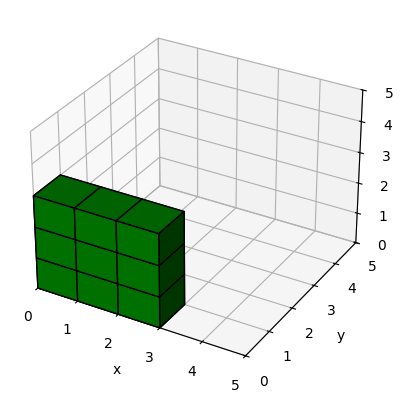

In [44]:

# przykład zaczerpnięty z: https://matplotlib.org/stable/gallery/mplot3d/voxels.html#sphx-glr-gallery-mplot3d-voxels-py

import matplotlib.pyplot as plt

# inicjalizacja tablicy 3 x 3 x 3
# współrzędne (x, z, y)
x = np.ones((3, 3, 3))

# po prawej stosujemy filtrowanie tablicy x warunkiem < 3, co powoduje zwrócenie
# tablicy o tych samych wymiarach, gdzie wartość spełniająca warunek zostanie
# zapisana jako wartość logiczna True, a jeżeli go nie spełnia - jako False
# chociaż można tej konwersji dokonać na kilka sposobów
cube1 = (x < 3)

# sprawdzamy co jest teraz w środku tej tablicy
display(cube1)

# cube1[:,:,1] = False
# cube1[1,:,:] = False
cube1[:,2,:] = False
cube1[:,1,:] = False
print(cube1)

colors = np.empty(cube1.shape, dtype=object)
colors[cube1] = 'green'

ax = plt.figure().add_subplot(projection='3d')
ax.axes.set_xlim3d(left=0, right=5)
ax.axes.set_ylim3d(bottom=0, top=5)
ax.axes.set_zlim3d(bottom=0, top=5)
ax.voxels(cube1, facecolors=colors, edgecolor='k')


plt.xlabel('x')
plt.ylabel('y')
plt.show()


array([[[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]],

       [[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]],

       [[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]]])

[[[ True False  True]
  [ True False  True]
  [ True False  True]]

 [[ True False  True]
  [ True False  True]
  [ True False  True]]

 [[ True False  True]
  [ True False  True]
  [ True False  True]]]


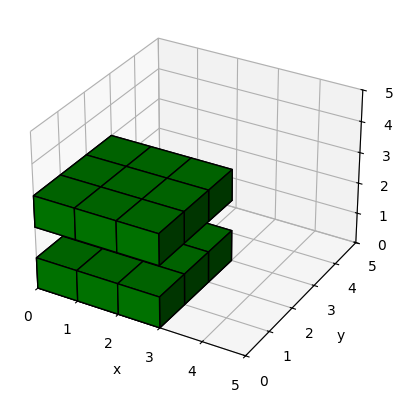

In [48]:

# przykład zaczerpnięty z: https://matplotlib.org/stable/gallery/mplot3d/voxels.html#sphx-glr-gallery-mplot3d-voxels-py

import matplotlib.pyplot as plt

# inicjalizacja tablicy 3 x 3 x 3
# współrzędne (x, z, y)
x = np.ones((3, 3, 3))

# po prawej stosujemy filtrowanie tablicy x warunkiem < 3, co powoduje zwrócenie
# tablicy o tych samych wymiarach, gdzie wartość spełniająca warunek zostanie
# zapisana jako wartość logiczna True, a jeżeli go nie spełnia - jako False
# chociaż można tej konwersji dokonać na kilka sposobów
cube1 = (x < 3)

# sprawdzamy co jest teraz w środku tej tablicy
display(cube1)

# cube1[:,:,1] = False
# cube1[1,:,:] = False
cube1[:,:,1] = False
print(cube1)

colors = np.empty(cube1.shape, dtype=object)
colors[cube1] = 'green'

ax = plt.figure().add_subplot(projection='3d')
ax.axes.set_xlim3d(left=0, right=5)
ax.axes.set_ylim3d(bottom=0, top=5)
ax.axes.set_zlim3d(bottom=0, top=5)
ax.voxels(cube1, facecolors=colors, edgecolor='k')


plt.xlabel('x')
plt.ylabel('y')
plt.show()


Zad 6

In [1]:
from timeit import timeit
import numpy as np

setup_list_for_loop = """
my_list = list(range(1, 100001))
"""
stmt_list_for_loop = """
for i in range(len(my_list)):
    my_list[i] = my_list[i] * 2
"""

setup_list_comp = """
my_list = list(range(1, 100001))
"""
stmt_list_comp = """
my_list = [elem * 2 for elem in my_list]
"""

setup_numpy_arr = """
import numpy as np
my_arr = np.arange(1, 100001)
"""
stmt_numpy_arr = """
my_arr = my_arr * 2
"""

print("Time for Python list (for loop) multiplication (100 iterations):")
print(timeit(stmt=stmt_list_for_loop, setup=setup_list_for_loop, number=100))

print("\nTime for Python list (list comprehension) multiplication (100 iterations):")
print(timeit(stmt=stmt_list_comp, setup=setup_list_comp, number=100))

print("\nTime for NumPy array multiplication (100 iterations):")
print(timeit(stmt=stmt_numpy_arr, setup=setup_numpy_arr, number=100))


Time for Python list (for loop) multiplication (100 iterations):
1.304197361999968

Time for Python list (list comprehension) multiplication (100 iterations):
2.6766317070000696

Time for NumPy array multiplication (100 iterations):
0.012838925000096424
